<a href="https://colab.research.google.com/github/Amirhossain959/geemap/blob/master/biomass_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade xee

In [ ]:
!pip install -U geemap

In [ ]:
import ee
import xee
import geemap
import xarray as xr

In [ ]:
ee.Authenticate()
ee.Initialize(
    project='roads-and-highways',
    opt_url='https://earthengine-highvolume.googleapis.com'
)

In [ ]:
Map=geemap.Map()
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:
roi=Map.draw_last_feature.geometry()
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          88.128871,
                          20.653346
                        ],
                        [
                          88.128871,
                          26.450902
                        ],
                        [
                          92.654238,
                          26.450902
                        ],
                        [
                          92.654238,
                          20.653346
                        ],
                        [
                          88.128871,
                          20.653346
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [ ]:
biomass= (
    ee.ImageCollection("NASA/ORNL/biomass_carbon_density/v1").select('agb')
    .first()
    .rename('biomass')
)

ndvi= (
    ee.ImageCollection("MODIS/061/MOD13A2")
    .select(['NDVI', 'EVI'])
    .filterDate('2010', '2011')
    .mean()
    .rename(['ndvi', 'evi'])
)

lai=(
    ee.ImageCollection("MODIS/061/MOD15A2H")
    .select(['Lai_500m', 'Fpar_500m'])
    .filterDate('2010', '2011')
    .mean()
    .rename(['lai', 'fpar'])
)

lst=(
    ee.ImageCollection("MODIS/061/MYD11A2")
    .select('LST_Day_1km')
    .filterDate('2010', '2011')
    .mean()
    .rename('lst')
)

pr=(
    ee.ImageCollection("NASA/GPM_L3/IMERG_MONTHLY_V07")
    .select('precipitation')
    .filterDate('2010', '2011')
    .sum()
    .rename('pr')
)

lc= (
    ee.ImageCollection("MODIS/061/MCD12Q1")
    .select('LC_Type1')
    .filterDate('2010', '2011')
    .mode()
    .rename('lc')
)

stack= ee.Image.cat([ndvi, lai, lst, pr, lc, biomass])
stack

In [ ]:
ds = xr.open_dataset(
    stack,
    engine='ee',
    crs='epsg:4326',
    scale= 0.1,
    geometry=roi
)

In [ ]:
ds= ds.sortby('time')*1
ds

<xarray.Dataset> Size: 84kB
Dimensions:  (time: 1, lon: 45, lat: 58)
Coordinates:
  * time     (time) int64 8B 0
  * lon      (lon) float64 360B 88.18 88.28 88.38 88.48 ... 92.38 92.48 92.58
  * lat      (lat) float64 464B 20.7 20.8 20.9 21.0 21.1 ... 26.1 26.2 26.3 26.4
Data variables:
    ndvi     (time, lon, lat) float32 10kB nan nan nan ... 5.556e+03 5.081e+03
    evi      (time, lon, lat) float32 10kB nan nan nan ... 3.165e+03 2.719e+03
    lai      (time, lon, lat) float32 10kB nan nan nan nan ... 9.783 10.96 8.652
    fpar     (time, lon, lat) float32 10kB nan nan nan nan ... 39.61 40.67 35.22
    lst      (time, lon, lat) float32 10kB nan nan nan ... 1.513e+04 1.509e+04
    pr       (time, lon, lat) float32 10kB 3.088 2.922 2.892 ... 3.061 2.977
    lc       (time, lon, lat) float32 10kB 17.0 17.0 17.0 ... 12.0 14.0 12.0
    biomass  (time, lon, lat) float32 10kB nan nan nan nan ... 5.092 8.719 8.565
Attributes:
    crs:      epsg:4326

In [ ]:
df=ds.to_dataframe()
df=df.dropna()
df

ndvi          evi        lai       fpar  \
time lon       lat                                                         
0    88.178871 21.603346  2985.695557  1817.260864   5.630435  24.217392   
               21.703346  3315.869629  2090.130371   6.065217  26.478260   
               21.803346  4253.260742  2582.173828   8.021739  32.130436   
               21.903346  4380.478027  2634.086914   7.652174  31.891304   
               22.003346  1582.826050  1044.434814   7.130435  29.869566   
...                               ...          ...        ...        ...   
     92.578871 26.003346  5630.608887  3689.086914  12.391304  45.760868   
               26.103346  5170.434570  3112.434814  10.934783  41.282608   
               26.203346  5282.391113  3055.043457   9.782609  39.608696   
               26.303346  5556.304199  3165.173828  10.956522  40.673912   
               26.403346  5081.260742  2718.739014   8.652174  35.217392   

                                   lst     pr    lc    biomass  
time lon       lat                                              
0    88.178871 21.603346  15163.371094  2.286  17.0   1.250890  
               21.703346  15203.351562  2.481  12.0   1.369249  
               21.803346  15204.942383  2.377  12.0   1.380744  
               21.903346  15212.666992  2.184  12.0   2.074669  
               22.003346  15051.625000  2.024  17.0   1.278513  
...                                ...    ...   ...        ...  
     92.578871 26.003346  15143.027344  3.398  12.0  31.219185  
               26.103346  15067.769531  3.307  12.0   9.282629  
               26.203346  15119.735352  3.161  12.0   5.091849  
               26.303346  15127.793945  3.061  14.0   8.718756  
               26.403346  15088.918945  2.977  12.0   8.565279  

[2144 rows x 8 columns]

In [ ]:
# x1=df[['ndvi', 'evi', 'lai', 'fpar', 'lst', 'pr', 'lc']]
x= df.drop(columns=['biomass'])
y=df['biomass']
y

time  lon        lat      
0     88.178871  21.603346     1.250890
                 21.703346     1.369249
                 21.803346     1.380744
                 21.903346     2.074669
                 22.003346     1.278513
                                ...    
      92.578871  26.003346    31.219185
                 26.103346     9.282629
                 26.203346     5.091849
                 26.303346     8.718756
                 26.403346     8.565279
Name: biomass, Length: 2144, dtype: float32

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=42)

In [ ]:
from xgboost import XGBRegressor

In [ ]:
model= XGBRegressor(
    n_estimator=100,
    random_state=42
)

In [ ]:
model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimator=100,
             n_estimators=None, n_jobs=None, ...)

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
import numpy as np

In [ ]:
rmse=np.sqrt(mean_squared_error(y_test, y_pred))
r2=r2_score(y_test, y_pred)
print(f'RMSE: {rmse}')
print(f'R2: {r2}')

RMSE: 6.887837579280938
R2: 0.8896039724349976


In [ ]:
df['predicted_biomass']=model.predict(x)

In [ ]:
df

ndvi          evi        lai       fpar  \
time lon       lat                                                         
0    88.178871 21.603346  2985.695557  1817.260864   5.630435  24.217392   
               21.703346  3315.869629  2090.130371   6.065217  26.478260   
               21.803346  4253.260742  2582.173828   8.021739  32.130436   
               21.903346  4380.478027  2634.086914   7.652174  31.891304   
               22.003346  1582.826050  1044.434814   7.130435  29.869566   
...                               ...          ...        ...        ...   
     92.578871 26.003346  5630.608887  3689.086914  12.391304  45.760868   
               26.103346  5170.434570  3112.434814  10.934783  41.282608   
               26.203346  5282.391113  3055.043457   9.782609  39.608696   
               26.303346  5556.304199  3165.173828  10.956522  40.673912   
               26.403346  5081.260742  2718.739014   8.652174  35.217392   

                                   lst     pr    lc    biomass  \
time lon       lat                                               
0    88.178871 21.603346  15163.371094  2.286  17.0   1.250890   
               21.703346  15203.351562  2.481  12.0   1.369249   
               21.803346  15204.942383  2.377  12.0   1.380744   
               21.903346  15212.666992  2.184  12.0   2.074669   
               22.003346  15051.625000  2.024  17.0   1.278513   
...                                ...    ...   ...        ...   
     92.578871 26.003346  15143.027344  3.398  12.0  31.219185   
               26.103346  15067.769531  3.307  12.0   9.282629   
               26.203346  15119.735352  3.161  12.0   5.091849   
               26.303346  15127.793945  3.061  14.0   8.718756   
               26.403346  15088.918945  2.977  12.0   8.565279   

                          predicted_biomass  
time lon       lat                           
0    88.178871 21.603346           1.824523  
               21.703346           2.082705  
               21.803346           1.965670  
               21.903346           2.359981  
               22.003346           2.235502  
...                                     ...  
     92.578871 26.003346          29.858915  
               26.103346           8.685362  
               26.203346          10.762707  
               26.303346           9.162972  
               26.403346           9.251648  

[2144 rows x 9 columns]

In [ ]:
xarr=df.to_xarray().sortby('lon').sortby('lat')
xarr

<xarray.Dataset> Size: 95kB
Dimensions:            (time: 1, lon: 45, lat: 58)
Coordinates:
  * time               (time) int64 8B 0
  * lon                (lon) float64 360B 88.18 88.28 88.38 ... 92.48 92.58
  * lat                (lat) float64 464B 20.7 20.8 20.9 21.0 ... 26.2 26.3 26.4
Data variables:
    ndvi               (time, lon, lat) float32 10kB nan nan ... 5.081e+03
    evi                (time, lon, lat) float32 10kB nan nan ... 2.719e+03
    lai                (time, lon, lat) float32 10kB nan nan nan ... 10.96 8.652
    fpar               (time, lon, lat) float32 10kB nan nan nan ... 40.67 35.22
    lst                (time, lon, lat) float32 10kB nan nan ... 1.509e+04
    pr                 (time, lon, lat) float32 10kB nan nan nan ... 3.061 2.977
    lc                 (time, lon, lat) float32 10kB nan nan nan ... 14.0 12.0
    biomass            (time, lon, lat) float32 10kB nan nan nan ... 8.719 8.565
    predicted_biomass  (time, lon, lat) float32 10kB nan nan nan ... 9.163 9.252

In [ ]:
import matplotlib.pyplot as plt

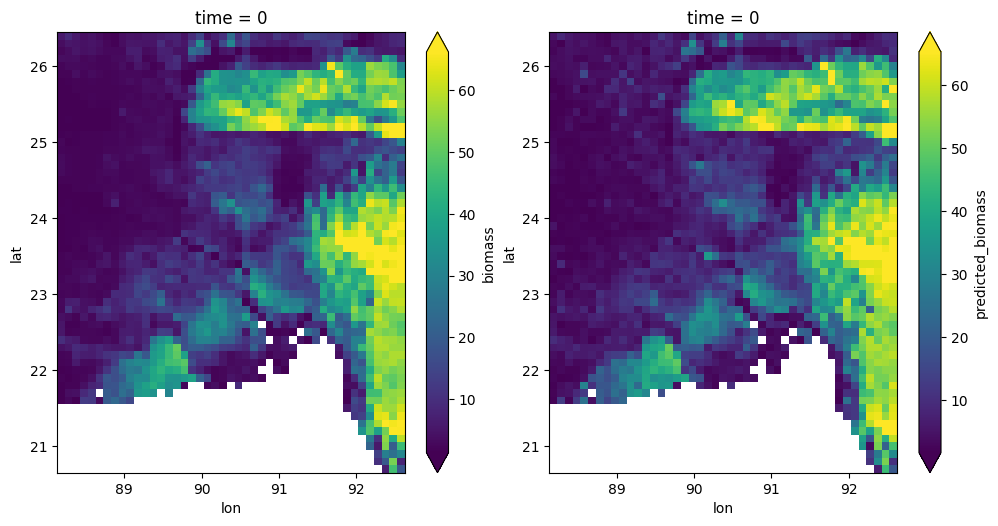

In [ ]:
fig, ax=plt.subplots(1, 2, figsize=(10,5))
plt.tight_layout()

xarr.biomass.plot(
    ax=ax[0],
    x='lon',
    y='lat',
    robust=True,
)

xarr.predicted_biomass.plot(
    ax=ax[1],
    x='lon',
    y='lat',
    robust=True,
)


In [ ]:
time_start=ee.Date('2015')
time_end=ee.Date('2016')

time_start, time_end

ndvi= (
    ee.ImageCollection("MODIS/061/MOD13A2")
    .select(['NDVI', 'EVI'])
    .filterDate(time_start, time_end)
    .mean()
    .rename(['ndvi', 'evi'])
)

lai=(
    ee.ImageCollection("MODIS/061/MOD15A2H")
    .select(['Lai_500m', 'Fpar_500m'])
    .filterDate(time_start, time_end)
    .mean()
    .rename(['lai', 'fpar'])
)

lst=(
    ee.ImageCollection("MODIS/061/MYD11A2")
    .select('LST_Day_1km')
    .filterDate(time_start, time_end)
    .mean()
    .rename('lst')
)

pr=(
    ee.ImageCollection("NASA/GPM_L3/IMERG_MONTHLY_V07")
    .select('precipitation')
    .filterDate(time_start, time_end)
    .sum()
    .rename('pr')
)

lc= (
    ee.ImageCollection("MODIS/061/MCD12Q1")
    .select('LC_Type1')
    .filterDate(time_start, time_end)
    .mode()
    .rename('lc')
)

stack2015= ee.Image.cat([ndvi, lai, lst, pr, lc])
stack2015

In [ ]:
ds2015=xr.open_dataset(
    stack2015,
    engine='ee',
    crs='epsg:4326',
    scale= 0.1,
    geometry=roi
)
ds2015

<xarray.Dataset> Size: 74kB
Dimensions:  (time: 1, lon: 45, lat: 58)
Coordinates:
  * time     (time) int64 8B 0
  * lon      (lon) float64 360B 88.18 88.28 88.38 88.48 ... 92.38 92.48 92.58
  * lat      (lat) float64 464B 20.7 20.8 20.9 21.0 21.1 ... 26.1 26.2 26.3 26.4
Data variables:
    ndvi     (time, lon, lat) float32 10kB ...
    evi      (time, lon, lat) float32 10kB ...
    lai      (time, lon, lat) float32 10kB ...
    fpar     (time, lon, lat) float32 10kB ...
    lst      (time, lon, lat) float32 10kB ...
    pr       (time, lon, lat) float32 10kB ...
    lc       (time, lon, lat) float32 10kB ...
Attributes:
    crs:      epsg:4326

In [ ]:
df2015=ds2015.to_dataframe().dropna()
df2015

ndvi          evi        lai       fpar  \
time lon       lat                                                         
0    88.178871 21.603346  3162.739014  1926.739136   6.239130  26.413044   
               21.703346  3565.565186  2239.913086   6.760870  29.369566   
               21.803346  4420.304199  2709.043457   8.652174  34.934784   
               21.903346  4585.826172  2763.391357   8.717391  35.130436   
               22.003346  1764.391357  1113.782593   7.173913  31.326086   
...                               ...          ...        ...        ...   
     92.578871 26.003346  5521.086914  3563.391357  12.782609  46.347828   
               26.103346  5624.043457  3369.478271  12.586957  45.586956   
               26.203346  5387.347656  3181.478271  11.500000  44.108696   
               26.303346  5670.826172  3357.130371  13.456522  46.086956   
               26.403346  5530.695801  2946.347900  10.500000  40.217392   

                                   lst     pr    lc  
time lon       lat                                   
0    88.178871 21.603346  15191.594727  2.660  17.0  
               21.703346  15207.638672  2.648  12.0  
               21.803346  15212.077148  2.766  12.0  
               21.903346  15226.837891  2.796  12.0  
               22.003346  15094.500000  2.662  17.0  
...                                ...    ...   ...  
     92.578871 26.003346  15221.000000  2.711  12.0  
               26.103346  15153.205078  2.647  12.0  
               26.203346  15158.900391  2.548  12.0  
               26.303346  15144.424805  2.418  12.0  
               26.403346  15088.810547  2.367  12.0  

[2153 rows x 7 columns]

In [ ]:
df2015['biomass2015']=model.predict(df2015[['ndvi', 'evi', 'lai', 'fpar', 'lst', 'pr', 'lc']])
df2015

ndvi          evi        lai       fpar  \
time lon       lat                                                         
0    88.178871 21.603346  3162.739014  1926.739136   6.239130  26.413044   
               21.703346  3565.565186  2239.913086   6.760870  29.369566   
               21.803346  4420.304199  2709.043457   8.652174  34.934784   
               21.903346  4585.826172  2763.391357   8.717391  35.130436   
               22.003346  1764.391357  1113.782593   7.173913  31.326086   
...                               ...          ...        ...        ...   
     92.578871 26.003346  5521.086914  3563.391357  12.782609  46.347828   
               26.103346  5624.043457  3369.478271  12.586957  45.586956   
               26.203346  5387.347656  3181.478271  11.500000  44.108696   
               26.303346  5670.826172  3357.130371  13.456522  46.086956   
               26.403346  5530.695801  2946.347900  10.500000  40.217392   

                                   lst     pr    lc  biomass2015  
time lon       lat                                                
0    88.178871 21.603346  15191.594727  2.660  17.0     7.164640  
               21.703346  15207.638672  2.648  12.0     4.805734  
               21.803346  15212.077148  2.766  12.0     6.018824  
               21.903346  15226.837891  2.796  12.0     5.731117  
               22.003346  15094.500000  2.662  17.0     6.420905  
...                                ...    ...   ...          ...  
     92.578871 26.003346  15221.000000  2.711  12.0    16.469561  
               26.103346  15153.205078  2.647  12.0    18.862020  
               26.203346  15158.900391  2.548  12.0    16.858404  
               26.303346  15144.424805  2.418  12.0    12.718479  
               26.403346  15088.810547  2.367  12.0     8.102068  

[2153 rows x 8 columns]

In [ ]:
xarr2015=df2015.to_xarray().sortby('lon').sortby('lat')
xarr2015

<xarray.Dataset> Size: 84kB
Dimensions:      (time: 1, lon: 45, lat: 58)
Coordinates:
  * time         (time) int64 8B 0
  * lon          (lon) float64 360B 88.18 88.28 88.38 ... 92.38 92.48 92.58
  * lat          (lat) float64 464B 20.7 20.8 20.9 21.0 ... 26.1 26.2 26.3 26.4
Data variables:
    ndvi         (time, lon, lat) float32 10kB nan nan ... 5.671e+03 5.531e+03
    evi          (time, lon, lat) float32 10kB nan nan ... 3.357e+03 2.946e+03
    lai          (time, lon, lat) float32 10kB nan nan nan ... 11.5 13.46 10.5
    fpar         (time, lon, lat) float32 10kB nan nan nan ... 44.11 46.09 40.22
    lst          (time, lon, lat) float32 10kB nan nan ... 1.514e+04 1.509e+04
    pr           (time, lon, lat) float32 10kB nan nan nan ... 2.548 2.418 2.367
    lc           (time, lon, lat) float32 10kB nan nan nan ... 12.0 12.0 12.0
    biomass2015  (time, lon, lat) float32 10kB nan nan nan ... 16.86 12.72 8.102

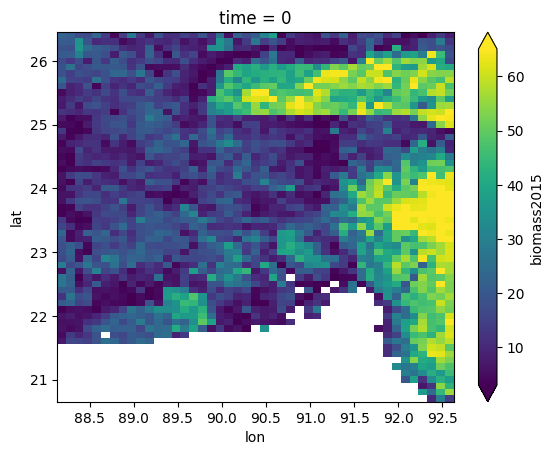

In [ ]:
xarr2015.biomass2015.plot(
    x='lon',
    y='lat',
    robust=True,
)


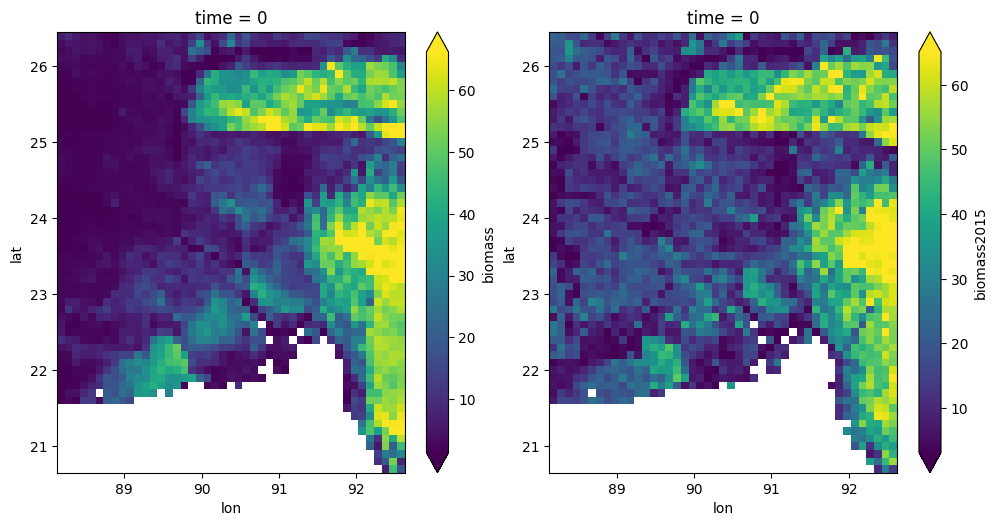

In [ ]:
fig, ax= plt.subplots(1, 2, figsize=(10,5))
plt.tight_layout()

xarr.biomass.plot(
    ax=ax[0],
    x='lon',
    y='lat',
    robust=True
)

xarr2015.biomass2015.plot(
    ax=ax[1],
    x='lon',
    y='lat',
    robust=True
)